# E2 Latent Steering — Results
Set `DECODER` and `METHOD` then run all cells.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Edit these ────────────────────────────────────────────────────────────────
DECODER     = "whisper"          # "whisper" | "whisfusion"
METHOD      = "full_dtw"              # "dtw" | "position"
RESULTS_DIR = Path("/vol/gpudata/tsv22-fyp/accent-robust-asr/results/e2_steering")
# ─────────────────────────────────────────────────────────────────────────────

sns.set_style("whitegrid")
print(f"decoder={DECODER}  method={METHOD}")
print(f"results dir: {RESULTS_DIR}")

decoder=whisper  method=full_dtw
results dir: /vol/gpudata/tsv22-fyp/accent-robust-asr/results/e2_steering


In [32]:
csv_path = RESULTS_DIR / f"{DECODER}_{METHOD}_steering.csv"
assert csv_path.exists(), f"Not found: {csv_path}"

df = pd.read_csv(csv_path)
df["alpha"] = pd.to_numeric(df["alpha"])
print(f"Loaded {len(df)} rows — {df['L1'].nunique()} L1s, {df['alpha'].nunique()} alpha values")
print(df.groupby("alpha")["wer"].agg(["mean","std"]).round(4))

AssertionError: Not found: /vol/gpudata/tsv22-fyp/accent-robust-asr/results/e2_steering/whisper_full_dtw_steering.csv

In [29]:
def _stats(sub):
    s = sub.groupby("alpha")["wer"].agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / len(x)**0.5
    ).reset_index().sort_values("alpha")
    return s

def _plot_pair(ax_w, ax_d, sub, title):
    stats    = _stats(sub)
    alphas   = stats["alpha"].values
    wers     = stats["mean"].values
    sems     = stats["sem"].values
    baseline = stats.loc[stats["alpha"] == 0.0, "mean"].values[0]
    deltas   = wers - baseline
    best_i   = int(np.argmin(wers))

    # WER — blue with error bars, best point highlighted
    ax_w.errorbar(alphas, wers, yerr=sems, fmt="o-", lw=2, ms=6,
                  color="steelblue", ecolor="steelblue", elinewidth=1.2,
                  capsize=3, zorder=2)
    ax_w.plot(alphas[best_i], wers[best_i], "o", ms=11,
              color="lightsteelblue", mec="steelblue", mew=2.5, zorder=3,
              label=f"Best \u03b1={alphas[best_i]}  {wers[best_i]:.3f}")
    ax_w.axhline(baseline, color="dimgray", ls="--", lw=1.5,
                 label=f"L2 baseline  {baseline:.3f}")
    ax_w.set_title(title, fontweight="bold")
    ax_w.set_xlabel("\u03b1"); ax_w.set_ylabel("WER")
    ax_w.legend(fontsize=8); ax_w.grid(True, alpha=0.3)

    # \u0394WER — green with error bars, best point highlighted
    ax_d.errorbar(alphas, deltas, yerr=sems, fmt="o-", lw=2, ms=6,
                  color="#27ae60", ecolor="#27ae60", elinewidth=1.2,
                  capsize=3, zorder=2)
    ax_d.plot(alphas[best_i], deltas[best_i], "o", ms=11,
              color="#a9dfbf", mec="#1a7a45", mew=2.5, zorder=3)
    ax_d.axhline(0, color="dimgray", ls="--", lw=1.5)
    ax_d.set_title(f"{title} (\u0394WER)", fontweight="bold")
    ax_d.set_xlabel("\u03b1"); ax_d.set_ylabel("\u0394WER")
    ax_d.grid(True, alpha=0.3)

print("\u2713 Plot helpers defined")

✓ Plot helpers defined


✓ whisfusion_dtw_overall.png


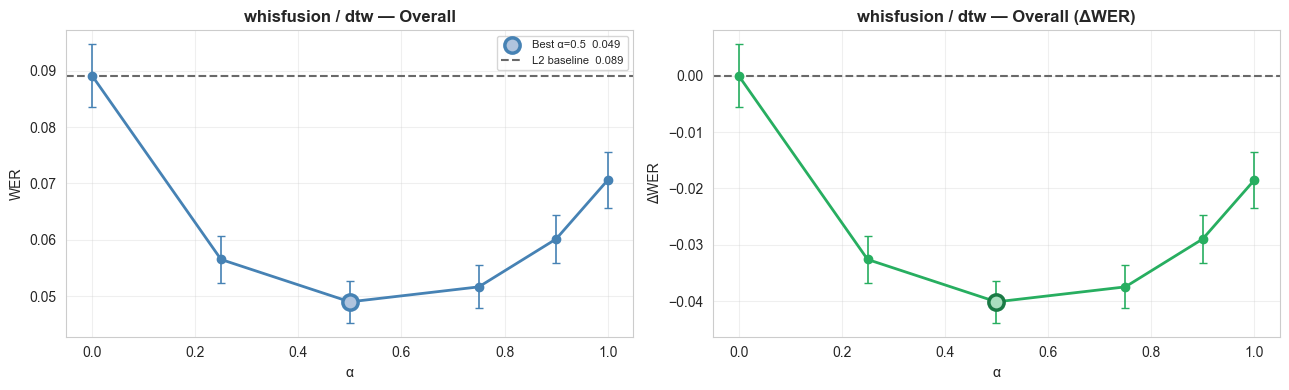

In [23]:
fig, (ax_w, ax_d) = plt.subplots(1, 2, figsize=(13, 4))
_plot_pair(ax_w, ax_d, df, f"{DECODER} / {METHOD} — Overall")
plt.tight_layout()
save = RESULTS_DIR / f"{DECODER}_{METHOD}_overall.png"
plt.savefig(save, dpi=150, bbox_inches="tight"); print(f"\u2713 {save.name}")
plt.show()

✓ whisfusion_dtw_per_l1.png


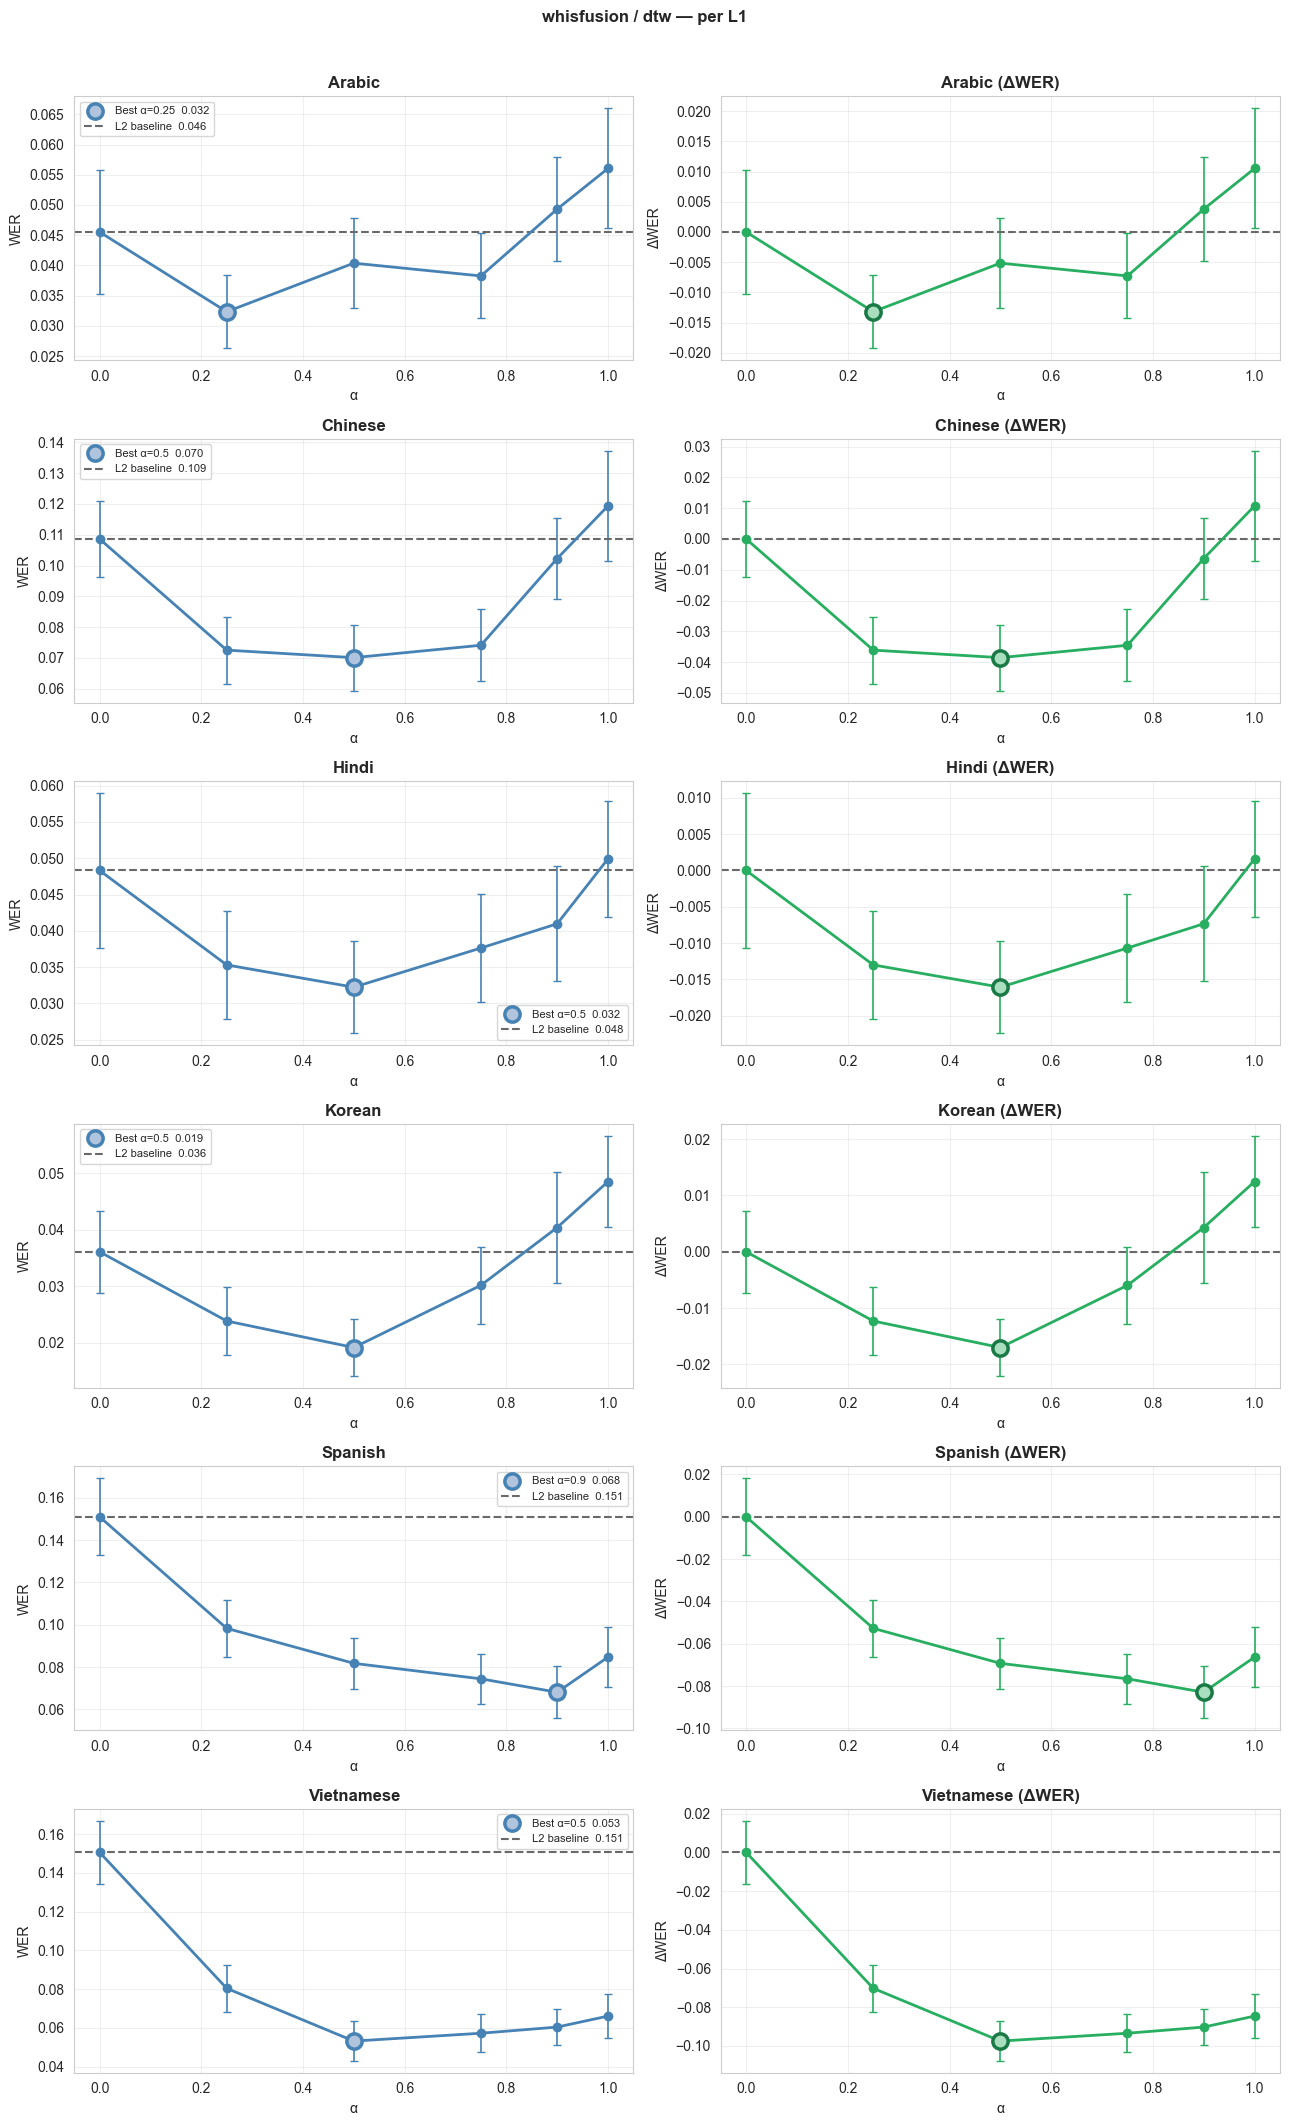

In [30]:
l1s = sorted(df["L1"].unique())
fig, axes = plt.subplots(len(l1s), 2, figsize=(13, 3.5 * len(l1s)))
for i, l1 in enumerate(l1s):
    _plot_pair(axes[i, 0], axes[i, 1], df[df["L1"] == l1], l1)
fig.suptitle(f"{DECODER} / {METHOD} — per L1", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
save = RESULTS_DIR / f"{DECODER}_{METHOD}_per_l1.png"
plt.savefig(save, dpi=150, bbox_inches="tight"); print(f"\u2713 {save.name}")
plt.show()